# Domain Adaptation with GRL

In this lab, we will implement the paper [_Unsupervised Domain Adaptation by Backpropagation_](https://arxiv.org/abs/1409.7495) which adapts between two domains using a Gradient Reversal Layer.

Our source domain will be **MNIST**, while our target domain will be **MNIST-M**. It is a modified version of MNIST with various color.

### Loading data

We will use only a subset of the datasets to be faster, but feel free to use all the datasets if you have a GPU.

In [1]:
import numpy as np

USE_SUBSET = True

def get_subset(x, y):
    if not USE_SUBSET:
        return x, y

    subset_index = 10000
    np.random.seed(1)
    indexes = np.random.permutation(len(x))[:subset_index]
    x, y = x[indexes], y[indexes]

    return x, y

Loading source dataset MNIST:

In [2]:
from tensorflow.keras.datasets import mnist
from skimage.color import gray2rgb
from skimage.transform import resize
from sklearn.model_selection import train_test_split

(x_source_train, y_source_train), (x_source_test, y_source_test) = mnist.load_data()

def process_mnist(x):
    x = np.moveaxis(x, 0, -1)
    x = resize(x, (32, 32), anti_aliasing=True, mode='constant')
    x = np.moveaxis(x, -1, 0)
    return gray2rgb(x).astype("float32")

x_source_train = process_mnist(x_source_train)
x_source_test = process_mnist(x_source_test)

x_source_train, y_source_train = get_subset(x_source_train, y_source_train)
#x_source_test, y_source_test = get_subset(x_source_test, y_source_test)

x_source_train, x_source_val, y_source_train, y_source_val = train_test_split(
    x_source_train, y_source_train,
    test_size=int(0.1 * len(x_source_train))
)

x_source_train.shape, x_source_val.shape, x_source_test.shape

2026-05-08 01:29:04.086384: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-08 01:29:04.198241: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 01:29:04.201869: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 01:29:04.201885: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

((9000, 32, 32, 3), (1000, 32, 32, 3), (10000, 32, 32, 3))

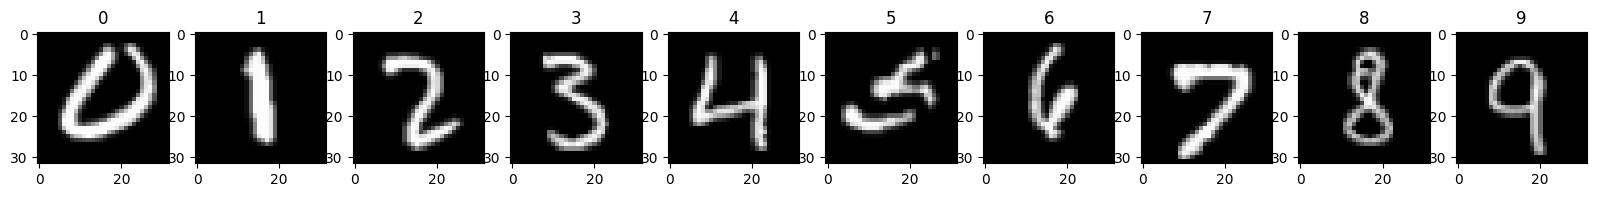

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
for i, digit in enumerate(np.unique(y_source_train), start=1):
    index = np.where(y_source_train == digit)[0][0]
    ax = plt.subplot(1, 10, i)
    ax.imshow(x_source_train[index])
    ax.set_title(digit)

Loading target dataset MNIST-M:

In [5]:
import pickle as pkl

with open("mnistm_data.pkl", "rb") as f:
    mnist_m = pkl.load(f)
    
x_target_train, y_target_train = get_subset(mnist_m["x_train"], mnist_m["y_train"])
x_target_test, y_target_test = mnist_m["x_test"], mnist_m["y_test"]

x_target_train = resize(x_target_train, (x_target_train.shape[0], 32, 32, 3), anti_aliasing=True, mode='edge').astype("float32")
x_target_test = resize(x_target_test, (x_target_test.shape[0], 32, 32, 3), anti_aliasing=True, mode='edge').astype("float32")

x_target_train.shape, x_target_test.shape

((10000, 32, 32, 3), (10000, 32, 32, 3))

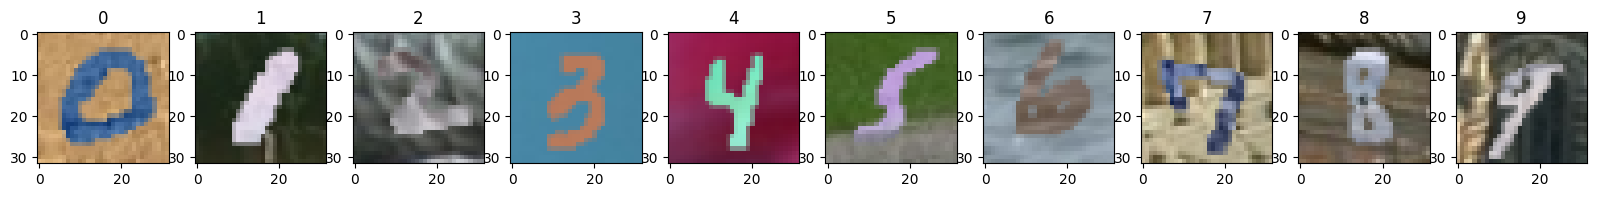

In [6]:
plt.figure(figsize=(20, 15))
for i, digit in enumerate(np.unique(y_target_train), start=1):
    index = np.where(y_target_train == digit)[0][0]
    ax = plt.subplot(1, 10, i)
    ax.imshow(x_target_train[index])
    ax.set_title(digit)

## Naive model

In the first step, we will build a naive model, depicted in the image below. Implement it as shown:

![cnn archi](images/cnn_archi_nogrl.png)

In [8]:
from tensorflow.keras.layers import (
    MaxPool2D,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    Input
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD

import tensorflow as tf


def get_network(input_shape=x_source_train.shape[1:]):

    inputs = Input(shape=input_shape)
    x = Conv2D(32, kernel_size=3, activation='relu')(inputs)
    x = MaxPool2D()(x)
    x = Conv2D(64, kernel_size=3, activation='relu')(x)
    x = MaxPool2D()(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    digits_classifier = Dense(10, activation='softmax')(x)

    return Model(inputs=inputs, outputs=digits_classifier)


model = get_network()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    metrics=['accuracy']
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 2304)              0     

2026-05-08 01:31:14.492656: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 01:31:14.509149: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 01:31:14.509197: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-05-08 01:31:14.509225: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-05-08 01:31:14.509250: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

In [10]:
# %load solutions/da_naive_model.py
from tensorflow.keras.layers import MaxPool2D, Conv2D, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
import tensorflow as tf


def get_network(input_shape=x_source_train.shape[1:]):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, 5, padding='same', activation='relu', name='conv2d_1')(inputs)
    x = MaxPool2D(pool_size=2, strides=2, name='max_pooling2d_1')(x)
    x = Conv2D(48, 5, padding='same', activation='relu', name='conv2d_2')(x)
    x = MaxPool2D(pool_size=2, strides=2, name='max_pooling2d_2')(x)
    x = Flatten(name='flatten_1')(x)
    x = Dense(100, activation='relu', name='dense_1')(x)
    x = Dense(100, activation='relu', name='dense_2')(x)
    digits_classifier = Dense(10, activation="softmax", name="digits_classifier")(x)

    return Model(inputs=inputs, outputs=digits_classifier)

model = get_network()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=SGD(lr=0.1, momentum=0.9, nesterov=True),
    metrics=['accuracy']
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        2432      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 48)        38448     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 8, 8, 48)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 3072)              0   

/home/zero/PE-II Lab/venv/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/gradient_descent.py:111: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [11]:
model.fit(
    x_source_train, y_source_train,
    validation_data=(x_source_val, y_source_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
71/71 [==============================] - 3s 43ms/step - loss: 2.3426 - accuracy: 0.1419 - val_loss: 2.3841 - val_accuracy: 0.1040
Epoch 2/10
71/71 [==============================] - 3s 39ms/step - loss: 2.3078 - accuracy: 0.1041 - val_loss: 2.3039 - val_accuracy: 0.1040
Epoch 3/10
71/71 [==============================] - 3s 40ms/step - loss: 2.3034 - accuracy: 0.1136 - val_loss: 2.3037 - val_accuracy: 0.1040
Epoch 4/10
71/71 [==============================] - 3s 41ms/step - loss: 2.3037 - accuracy: 0.1124 - val_loss: 2.3018 - val_accuracy: 0.1140
Epoch 5/10
71/71 [==============================] - 3s 42ms/step - loss: 2.3028 - accuracy: 0.1147 - val_loss: 2.3009 - val_accuracy: 0.1140
Epoch 6/10
71/71 [==============================] - 3s 43ms/step - loss: 2.3030 - accuracy: 0.1078 - val_loss: 2.3036 - val_accuracy: 0.1040
Epoch 7/10
71/71 [==============================] - 3s 41ms/step - loss: 2.3023 - accuracy: 0.1133 - val_loss: 2.3046 - val_accuracy: 0.1040
Epoch 8/10
71

After training on our **source dataset MNIST**, we evaluate our model performance on both the **source (MNIST)** and the **target dataset MNIST-M**:

In [12]:
print("Loss & Accuracy on MNIST test set:")
model.evaluate(x_source_test, y_source_test, verbose=0)

Loss & Accuracy on MNIST test set:


[2.3052406311035156, 0.11349999904632568]

In [13]:
print("Loss & Accuracy on MNIST-M test set:")
model.evaluate(x_target_test, y_target_test, verbose=0)

Loss & Accuracy on MNIST-M test set:


[2.3052406311035156, 0.11349999904632568]

Note that the two datasets are too different. The model didn't generalize on the target set.

### Model with Gradient Reversal Layer

![cnn archi](images/cnn_archi.png)

Let us first define a Gradient Rerversal Layer where we want to inverse the gradient:

In [16]:
@tf.custom_gradient
def grad_reverse(x):
    y = tf.identity(x)
    def custom_grad(dy):
        return None # TODO
    return y, custom_grad

class GradReverse(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__(name="grl")

    def call(self, x):
        return grad_reverse(x)

In [17]:
# %load solutions/grl.py
@tf.custom_gradient
def grad_reverse(x):
    y = tf.identity(x)
    def custom_grad(dy):
        return -dy
    return y, custom_grad

class GradReverse(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__(name="grl")

    def call(self, x):
        return grad_reverse(x)

Then define the whole model: convnet + classification branch + domain branch

In [19]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model


def get_adaptable_network(input_shape=x_source_train.shape[1:]):

    inputs = Input(shape=input_shape)
    x = Conv2D(32, kernel_size=3, activation='relu')(inputs)
    x = MaxPool2D()(x)
    x = Conv2D(64, kernel_size=3, activation='relu')(x)
    x = MaxPool2D()(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)
    
    return Model(inputs=inputs, outputs=outputs)


model = get_adaptable_network()
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0   

In [21]:
# %load solutions/da_model.py
def get_adaptable_network(input_shape=x_source_train.shape[1:]):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, 5, padding='same', activation='relu', name='conv2d_1')(inputs)
    x = MaxPool2D(pool_size=2, strides=2, name='max_pooling2d_1')(x)
    x = Conv2D(48, 5, padding='same', activation='relu', name='conv2d_2')(x)
    x = MaxPool2D(pool_size=2, strides=2, name='max_pooling2d_2')(x)
    features = Flatten(name='flatten_1')(x)
    x = Dense(100, activation='relu', name='dense_digits_1')(features)
    x = Dense(100, activation='relu', name='dense_digits_2')(x)
    digits_classifier = Dense(10, activation="softmax", name="digits_classifier")(x)

    domain_branch = Dense(100, activation="relu", name="dense_domain")(GradReverse()(features))
    domain_classifier = Dense(1, activation="sigmoid", name="domain_classifier")(domain_branch)

    return Model(inputs=inputs, outputs=[digits_classifier, domain_classifier])

model = get_adaptable_network()
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_1 (Conv2D)              (None, 32, 32, 32)   2432        ['input_4[0][0]']                
                                                                                                  
 max_pooling2d_1 (MaxPooling2D)  (None, 16, 16, 32)  0           ['conv2d_1[0][0]']               
                                                                                                  
 conv2d_2 (Conv2D)              (None, 16, 16, 48)   38448       ['max_pooling2d_1[0][0]']        
                                                                                            

We define our generators. Note that we also add the domain labels. We choose arbitrarily to set the source domain to 1, and the target domain to 0. 

In [22]:
batch_size = 128
epochs = 10

d_source_train = np.ones_like(y_source_train)
d_source_val = np.ones_like(y_source_val)

source_train_generator = tf.data.Dataset.from_tensor_slices(
    (x_source_train, y_source_train, d_source_train)).batch(batch_size)

d_target_train = np.zeros_like(y_target_train)

target_train_generator = tf.data.Dataset.from_tensor_slices(
    (x_target_train, d_target_train)
).batch(batch_size)

We want to train alternatively on the source and target dataset. Fill the following block. 

**Note that to work properly we set a low factor of 0.2 to the domain losses**.

See the documentation for more information on how to use GradientTape: [doc](https://www.tensorflow.org/tutorials/customization/custom_training_walkthrough#define_the_loss_and_gradient_function).

In [27]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy, BinaryCrossentropy
from tensorflow.keras.metrics import Mean, Accuracy
from tensorflow.keras.optimizers import SGD

import tensorflow as tf
import collections


optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

cce = SparseCategoricalCrossentropy()
bce = BinaryCrossentropy()

model.compile(
    optimizer=optimizer,
    loss=[cce, bce],
    metrics={
        "digits_classifier": "accuracy",
        "domain_classifier": "accuracy"
    }
)


def train_epoch(source_train_generator, target_train_generator):

    epoch_source_digits = tf.keras.metrics.Mean()
    epoch_source_domains = tf.keras.metrics.Mean()
    epoch_target_domains = tf.keras.metrics.Mean()

    epoch_accuracy = tf.keras.metrics.SparseCategoricalAccuracy()

    variables_but_classifier = list(
        filter(
            lambda x: "digits" not in x.name,
            model.trainable_variables
        )
    )

    loss_record = collections.defaultdict(list)

    for i, data in enumerate(
        zip(source_train_generator, target_train_generator)
    ):

        source_data, target_data = data
        x_source, y_source, d_source = source_data

        with tf.GradientTape() as tape:

            digits_prob, domains_prob = model(
                x_source,
                training=True
            )

            digits_loss = cce(y_source, digits_prob)
            domains_loss = bce(d_source, domains_prob)
            total_loss = digits_loss + domains_loss

        gradients = tape.gradient(
            total_loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(gradients, model.trainable_variables)
        )

        x_target, d_target = target_data

        with tf.GradientTape() as tape:

            _, target_domains_prob = model(
                x_target,
                training=True
            )

            target_loss = bce(
                d_target,
                target_domains_prob
            )

        gradients = tape.gradient(
            target_loss,
            variables_but_classifier
        )

        optimizer.apply_gradients(
            zip(gradients, variables_but_classifier)
        )

        epoch_source_digits(digits_loss)
        epoch_source_domains(domains_loss)
        epoch_accuracy(y_source, digits_prob)
        epoch_target_domains(target_loss)

    print(
        "Source digits loss={}, "
        "Source Accuracy={}, "
        "Source domain loss={}, "
        "Target domain loss={}".format(
            epoch_source_digits.result(),
            epoch_accuracy.result(),
            epoch_source_domains.result(),
            epoch_target_domains.result()
        )
    )


for epoch in range(epochs):

    print("Epoch: {}".format(epoch), end=" ")

    loss_record = train_epoch(
        source_train_generator,
        target_train_generator
    )

Epoch: 0 Source digits loss=2.300846576690674, Source Accuracy=0.11622222512960434, Source domain loss=0.6920232176780701, Target domain loss=0.6979860663414001
Epoch: 1 Source digits loss=2.300823450088501, Source Accuracy=0.11622222512960434, Source domain loss=0.6949617862701416, Target domain loss=0.6950253844261169
Epoch: 2 Source digits loss=2.3008275032043457, Source Accuracy=0.11622222512960434, Source domain loss=0.6949931383132935, Target domain loss=0.6949949860572815
Epoch: 3 Source digits loss=2.3008289337158203, Source Accuracy=0.11622222512960434, Source domain loss=0.6949946284294128, Target domain loss=0.6949946880340576
Epoch: 4 Source digits loss=2.300830125808716, Source Accuracy=0.11622222512960434, Source domain loss=0.6949946284294128, Target domain loss=0.6949946284294128
Epoch: 5 Source digits loss=2.300830364227295, Source Accuracy=0.11622222512960434, Source domain loss=0.6949946880340576, Target domain loss=0.6949946284294128
Epoch: 6 Source digits loss=2.30

This new model has more metrics & losses than the previous one. To know what they are we can display the `metrics_name`:

In [28]:
print(model.metrics_names)

[]


Evaluate the performance on both source and target dataset:

In [29]:
print("Loss & Accuracy on MNIST test set:")
model.evaluate(x_source_test, [y_source_test, np.ones_like(y_source_test)], verbose=0)

Loss & Accuracy on MNIST test set:


[2.996446371078491,
 2.3014516830444336,
 0.6949929594993591,
 0.11349999904632568,
 0.0]

In [30]:
print("Loss & Accuracy on MNIST-M test set:")
model.evaluate(x_target_test, [y_target_test, np.zeros_like(y_target_test)], verbose=0)

Loss & Accuracy on MNIST-M test set:


[2.9927549362182617,
 2.3014516830444336,
 0.6913028955459595,
 0.11349999904632568,
 1.0]

The model is still not as good on the target dataset (MNIST-M) than on the source dataset (MNIST), but the performance are much better!
Without using target labels we improve our performance from 40% of accuracy to more than 60% of accuracy.

**Homework**

- Train on the whole dataset
- Train for more epochs, use callbacks such as EarlyStopping to know when to stop
- Try to improve model by scheduling the learning rate as they do in the paper
- Try to improve model by scheduling the domain loss weight
- Try others domains, like SVHN -> MNIST